In [67]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

Load the data 

In [68]:
df=pd.read_csv(r"D:\resume_project\python -project\New York Airbnb-project\new_york_listings.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,2015-12-20,0.03,1,0,0,No License,5.0,1,1,Not specified
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,2023-05-01,0.24,139,364,2,No License,4.67,2,1,1
2,971353993633883038,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,2023-12-18,1.67,1,343,6,Exempt,4.17,1,2,1
3,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,2023-09-17,1.38,2,363,12,No License,4.64,1,1,1
4,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,2023-12-03,0.24,133,335,3,No License,4.91,Studio,1,1


In [69]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
20753,24736896,Rental unit in New York · ★4.75 · 1 bedroom · ...,186680487,Henry D,Manhattan,Lower East Side,40.711380,-73.991560,Private room,45.0,...,2023-09-29,1.81,1,157,12,No License,4.75,1,1,1
20754,2835711,Rental unit in New York · ★4.46 · 1 bedroom · ...,3237504,Aspen,Manhattan,Greenwich Village,40.730580,-74.000700,Entire home/apt,105.0,...,2023-07-01,0.48,1,0,1,No License,4.46,1,2,1
20755,51825274,Rental unit in New York · ★4.93 · 1 bedroom · ...,304317395,Jeff,Manhattan,Hell's Kitchen,40.757350,-73.993430,Entire home/apt,299.0,...,2023-12-08,2.09,1,0,27,No License,4.93,1,1,1
20756,782661008019550832,Rental unit in New York · ★5.0 · 1 bedroom · 1...,163083101,Marissa,Manhattan,Chinatown,40.713750,-73.991470,Entire home/apt,115.0,...,2023-09-17,0.91,1,363,7,No License,5.0,1,1,1
20757,566029911248687183,Rental unit in Queens · ★4.89 · 1 bedroom · 1 ...,93827372,Glenroy,Queens,Rosedale,40.658874,-73.728651,Private room,102.0,...,2023-12-10,4.50,1,0,62,OSE-STRREG-0000513,4.89,1,1,1


EDA the data


In [70]:
df.shape

(20758, 22)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   name                            20758 non-null  object 
 2   host_id                         20758 non-null  int64  
 3   host_name                       20758 non-null  object 
 4   neighbourhood_group             20758 non-null  object 
 5   neighbourhood                   20758 non-null  object 
 6   latitude                        20758 non-null  float64
 7   longitude                       20758 non-null  float64
 8   room_type                       20758 non-null  object 
 9   price                           20758 non-null  float64
 10  minimum_nights                  20758 non-null  int64  
 11  number_of_reviews               20758 non-null  int64  
 12  last_review                     

In [72]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,beds
count,2.075800e+04,2.075800e+04,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,3.034044e+17,1.749316e+08,40.726798,-73.939161,187.776616,28.558435,42.642596,1.257910,18.844108,205.990317,10.852105,1.723721
std,3.901216e+17,1.725541e+08,0.060294,0.061403,1022.797208,33.536518,73.561654,1.904661,70.910834,135.087768,21.357071,1.212272
min,2.595000e+03,1.678000e+03,40.500314,-74.249840,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000,1.000000
25%,2.708808e+07,2.041738e+07,40.684150,-73.980710,80.000000,30.000000,4.000000,0.210000,1.000000,87.000000,1.000000,1.000000
50%,4.993003e+07,1.087271e+08,40.722820,-73.949587,125.000000,30.000000,14.000000,0.650000,2.000000,215.000000,3.000000,1.000000
75%,7.216019e+17,3.144102e+08,40.763098,-73.917460,199.000000,30.000000,49.000000,1.800000,5.000000,353.000000,15.000000,2.000000
max,1.054376e+18,5.504035e+08,40.911147,-73.713650,100000.000000,1250.000000,1865.000000,75.490000,713.000000,365.000000,1075.000000,42.000000


In [73]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'rating',
       'bedrooms', 'beds', 'baths'],
      dtype='object')

In [74]:
df.nunique()

id                                20758
name                               9836
host_id                           12449
host_name                          5815
neighbourhood_group                   5
neighbourhood                       221
latitude                          15382
longitude                         14477
room_type                             4
price                               785
minimum_nights                       69
number_of_reviews                   470
last_review                        1878
reviews_per_month                   783
calculated_host_listings_count       68
availability_365                    366
number_of_reviews_ltm               153
license                             879
rating                              162
bedrooms                             12
beds                                 17
baths                                17
dtype: int64

data clean

In [75]:
df.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

In [76]:
df.duplicated().sum()

0

rooms per types 

In [77]:
room_types = df.groupby('room_type')['room_type'].value_counts()
room_types

room_type
Entire home/apt    11549
Hotel room           112
Private room        8804
Shared room          293
Name: count, dtype: int64

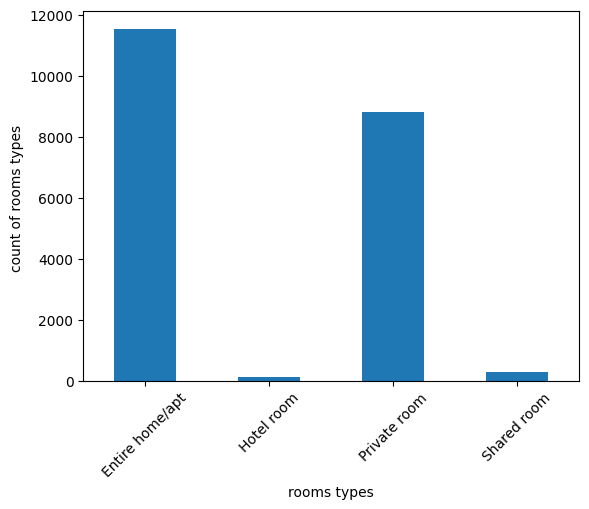

In [78]:
room_types = df.groupby('room_type')['room_type'].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.xlabel("rooms types")
plt.ylabel("count of rooms types ")
plt.show()


how many rooms have bath

In [79]:
room_baths=df.groupby('baths')['room_type'].value_counts()
room_baths

baths          room_type      
0              Private room         64
               Entire home/apt      16
               Shared room           2
1              Entire home/apt    9534
               Private room       7154
               Shared room         223
               Hotel room          104
1.5            Private room        601
               Entire home/apt     386
               Shared room          14
11.5           Private room          1
15.5           Entire home/apt       1
2              Entire home/apt    1201
               Private room        832
               Shared room          46
               Hotel room            3
2.5            Entire home/apt     184
               Private room         52
               Shared room           4
3              Entire home/apt     121
               Private room         43
               Hotel room            4
               Shared room           3
3.5            Entire home/apt      45
               Private room      

how many bedrooms in the rooms

In [80]:
bedrooms_rooms=df.groupby('bedrooms')['room_type'].value_counts()
bedrooms_rooms


bedrooms  room_type      
1         Private room       7827
          Entire home/apt    5278
          Shared room         238
          Hotel room           96
14        Entire home/apt       1
15        Entire home/apt       1
2         Entire home/apt    3064
          Private room        502
          Shared room          32
          Hotel room            4
3         Entire home/apt    1215
          Private room        160
          Shared room          16
          Hotel room            3
4         Entire home/apt     287
          Private room         55
          Hotel room            2
          Shared room           1
5         Entire home/apt      82
          Private room         29
          Shared room           1
6         Entire home/apt      27
          Private room          2
7         Entire home/apt       5
          Private room          3
          Shared room           1
8         Entire home/apt       3
          Private room          1
          Shared room 

rooms per price

In [81]:
room_price=df.groupby('price')['room_type'].value_counts()
room_price

price     room_type      
10.0      Entire home/apt    7
          Private room       2
14.0      Shared room        1
17.0      Private room       1
18.0      Private room       1
                            ..
9994.0    Private room       1
10000.0   Private room       3
          Entire home/apt    2
          Shared room        1
100000.0  Private room       2
Name: count, Length: 1348, dtype: int64

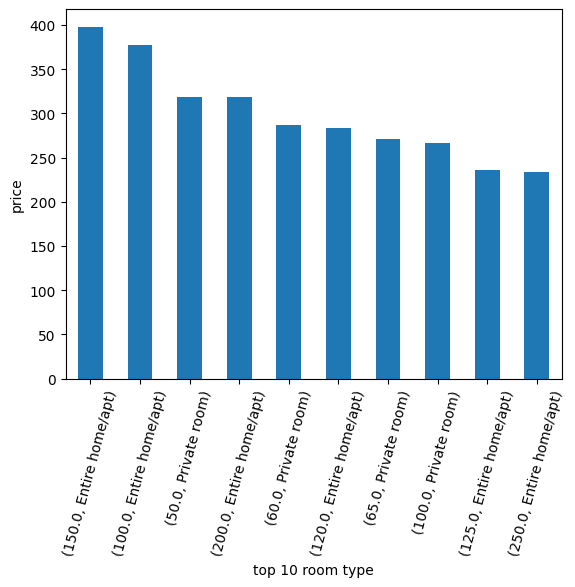

In [82]:
room_price=df.groupby('price')['room_type'].value_counts()
top10_room_price=room_price.nlargest(10)
top10_room_price.plot(kind='bar')
plt.xlabel("top 10 room type")
plt.xticks(rotation=75)
plt.ylabel("price")
plt.show()

In [83]:
room_max_price=df.groupby('price')['room_type'].max()
room_max_price

price
10.0        Private room
14.0         Shared room
17.0        Private room
18.0         Shared room
19.0        Private room
                ...     
7500.0      Private room
7590.0        Hotel room
9994.0      Private room
10000.0      Shared room
100000.0    Private room
Name: room_type, Length: 785, dtype: object

availability_Rooms

In [84]:
availability_rooms=df.groupby('room_type')['availability_365'].count()
availability_rooms

room_type
Entire home/apt    11549
Hotel room           112
Private room        8804
Shared room          293
Name: availability_365, dtype: int64

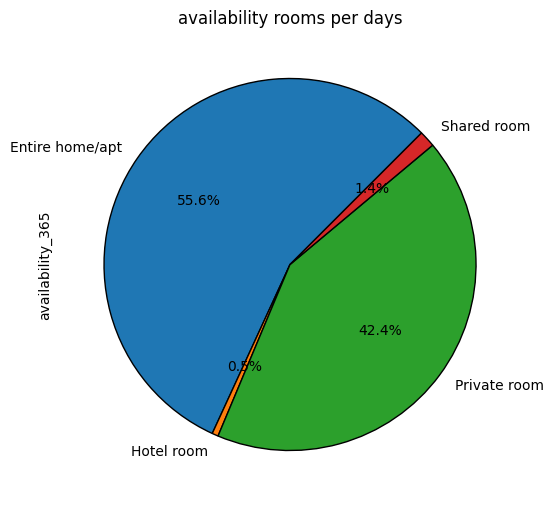

In [85]:
availability_rooms=df.groupby('room_type')['availability_365'].count().plot(kind='pie',
autopct="%1.1f%%",wedgeprops={"edgecolor": "black"},startangle=45,figsize=(6,8))

plt.title("availability rooms per days")
plt.show()



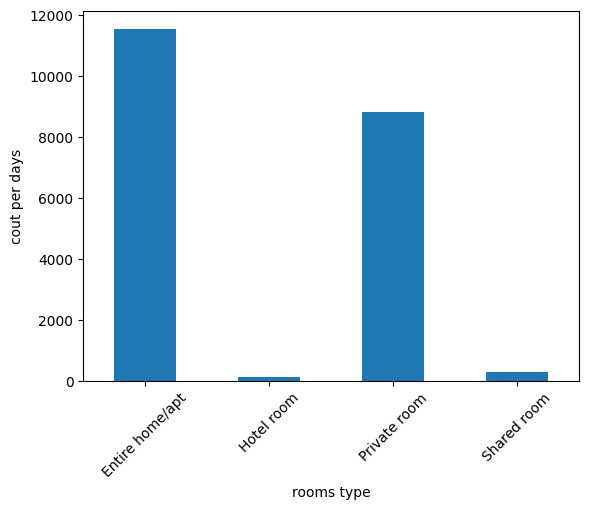

In [86]:
availability_rooms=df.groupby('room_type')['availability_365'].count().plot(kind='bar')
plt.xticks(rotation=45)
plt.ylabel('cout per days')
plt.xlabel('rooms type')
plt.show()


In [87]:
availability_rooms_max=df.groupby('room_type')['availability_365'].max()
availability_rooms_min=df.groupby('room_type')['availability_365'].min()
print(f"{"max of availability rooms", availability_rooms_max , "min of availability rooms",availability_rooms_min}")


('max of availability rooms', room_type
Entire home/apt    365
Hotel room         365
Private room       365
Shared room        365
Name: availability_365, dtype: int64, 'min of availability rooms', room_type
Entire home/apt    0
Hotel room         0
Private room       0
Shared room        0
Name: availability_365, dtype: int64)


neighbourhood by the price 

In [88]:
neighbourhood_price=df.groupby('neighbourhood')['price'].sum()
neighbourhood_price

neighbourhood
Allerton            3529.0
Arden Heights        535.0
Arrochar            1373.0
Arverne            13605.0
Astoria            40578.0
                    ...   
Windsor Terrace     9167.0
Woodhaven           6435.0
Woodlawn            1068.0
Woodrow              574.0
Woodside           13450.0
Name: price, Length: 221, dtype: float64

top10 price areas

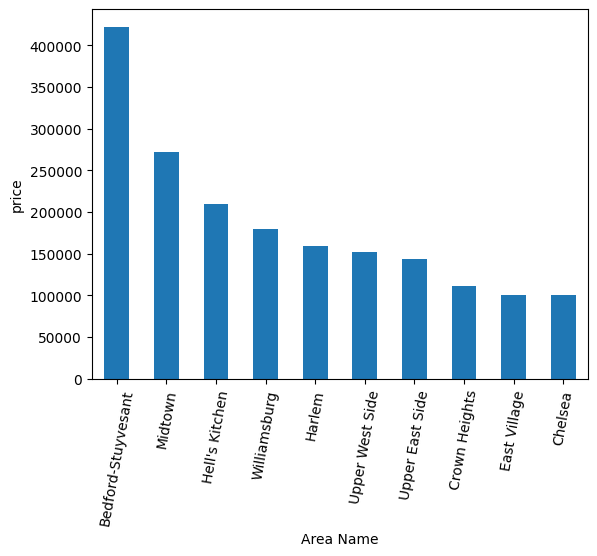

In [89]:
neighbourhood_price=df.groupby('neighbourhood')['price'].sum()
neighbourhood_price_top10=neighbourhood_price.nlargest(10)
neighbourhood_price_top10.plot(kind='bar')
plt.xlabel("Area Name")
plt.ylabel("price")
plt.xticks(rotation=80)
plt.show()



Lowest Area Prices 

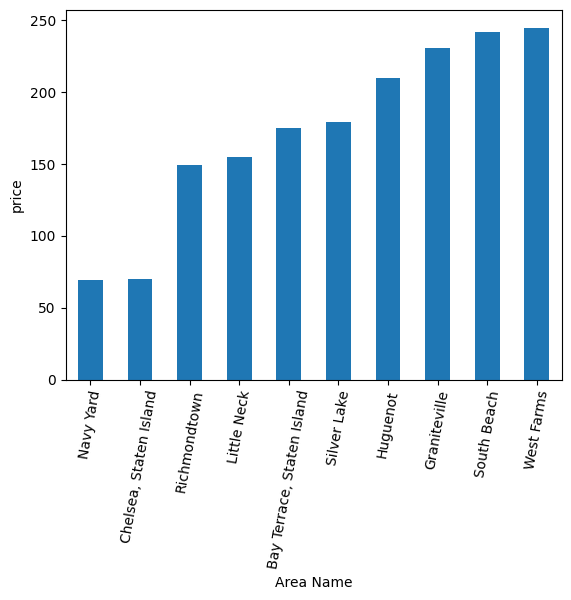

In [90]:
neighbourhood_price=df.groupby('neighbourhood')['price'].sum()
neighbourhood_price_low10=neighbourhood_price.nsmallest(10)
neighbourhood_price_low10.plot(kind='bar')
plt.xlabel("Area Name")
plt.ylabel("price")
plt.xticks(rotation=80)
plt.show()

top 10 rates rooms

In [99]:
"""replace all the values  with no rating by 0 and change then data type from object to int """
df['rating']=df['rating'].replace('No rating','0')
df['rating']=pd.to_numeric(df['rating'],errors='coerce')
top_rate_rooms=df.groupby('room_type')['rating'].sum()
top10_rate_rooms=top_rate_rooms.nlargest(10)
top10_rate_rooms
 

room_type
Entire home/apt    44916.47
Private room       34111.48
Shared room         1087.77
Hotel room           394.99
Name: rating, dtype: float64

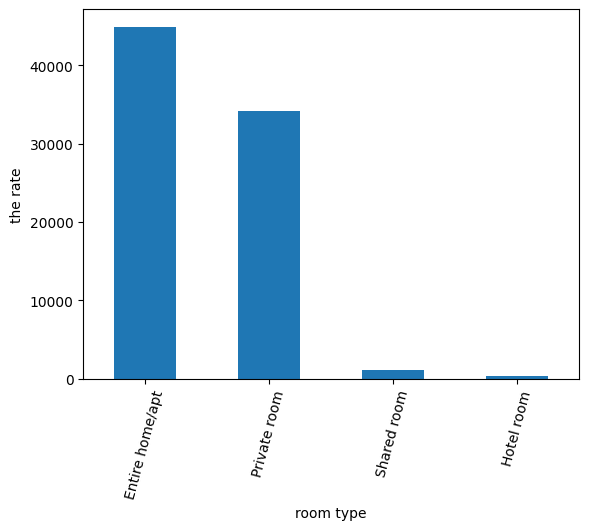

In [102]:
top10_rate_rooms.plot(kind='bar')
plt.xlabel("room type")
plt.xticks(rotation=75)
plt.ylabel("the rate")
plt.show()

calculated_host_listings_count by the host name 

In [120]:
host_count_list=df.groupby('host_name')['calculated_host_listings_count'].sum()
host_count_list

host_name
(Ari) HENRY LEE         1
-TheQueensCornerLot     1
475                     4
48Lex                  63
@ Art House Monique     1
                       ..
Андрей                  4
Ирина                   1
ゆりあ & Fredy             1
浩                       4
玉姗                      1
Name: calculated_host_listings_count, Length: 5815, dtype: int64

top 10 calculated_host_listings_count by the host name 

In [121]:
host_count_list.nlargest(10)

host_name
Blueground            76291
Urban Furnished       38996
Eugene                31810
Hiroki                23229
Jeniffer              20956
Shogo                 17430
Stay With Vibe        15029
Momoyo                14632
Furnished Quarters     9840
RoomPicks              7797
Name: calculated_host_listings_count, dtype: int64

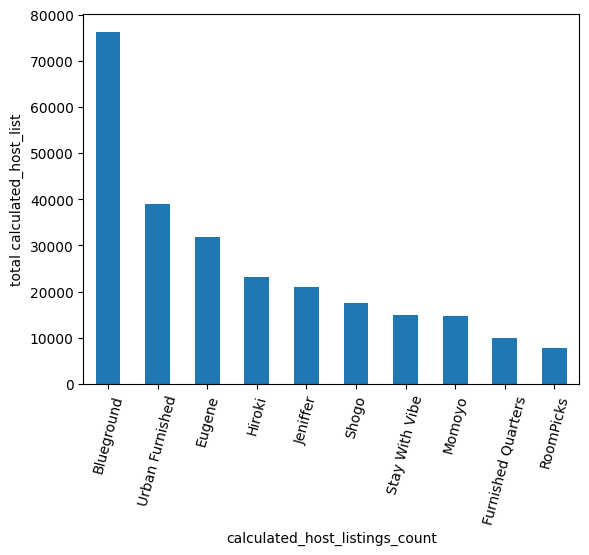

In [122]:
top10_host_count_list=host_count_list.nlargest(10)
top10_host_count_list.plot(kind='bar')
plt.xlabel("calculated_host_listings_count")
plt.ylabel("total calculated_host_list")
plt.xticks(rotation=75)
plt.show()

lowest 10 host count list

In [134]:
host_count_list.nsmallest(10)

host_name
(Ari) HENRY LEE        1
-TheQueensCornerLot    1
@ Art House Monique    1
A Group                1
A J                    1
A-B                    1
A.                     1
A. Beatriz             1
A.B.                   1
A.T.                   1
Name: calculated_host_listings_count, dtype: int64

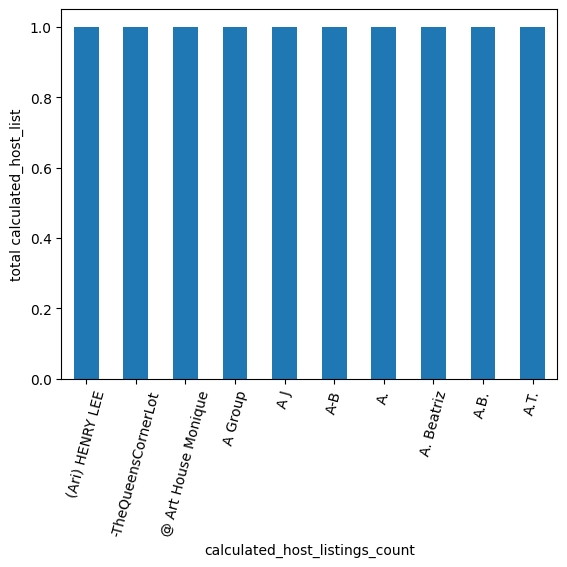

In [135]:
lowest10_host=host_count_list.nsmallest(10)
lowest10_host.plot(kind='bar')
plt.xlabel("calculated_host_listings_count")
plt.ylabel("total calculated_host_list")
plt.xticks(rotation=75)
plt.show()
